# Gaussian-categorical clustering as a Boltzmann machine


<div class="note"><span class="note-t">In brief</span>
<p>We learn to read a Gaussian mixture as a Boltzmann machine: one joint energy over a continuous visible vector and a categorical hidden unit. Fixing the visible vector turns that energy into a softmax over cluster labels, the responsibilities, and fixing the label turns it into a Gaussian, so those two conditionals are the whole model. We use the softmax to recover the clusters, where hard assignments exceed 99%, and then alternate the two conditionals in a Gibbs chain whose occupancy relaxes to the mixture weights.</p>
</div>

In this tutorial, we write a Gaussian mixture as one energy function and run it as a **Boltzmann machine** [(Ackley et al. 1985)](#ref-ackley-1985). One categorical hidden unit chooses the cluster, and a Gaussian visible vector describes points drawn from that cluster, so the whole model is a single energy with two kinds of variable inside it.

In Torx, the model uses the [continuous `pmode` and categorical `pdit`](01_introduction_to_parametrised_stochastic_circuits.ipynb) data primitives. The `pmode` carries the visible vector $v$, and the $K$-state `pdit` carries the one-hot hidden state $h$. We derive the joint Boltzmann kernel $p(v,h)\propto e^{-E(v,h)}$ on paper and then execute it through its two conditionals, which is why the code carries the parameters $(\mu_k,\Sigma_k,\pi_k)$ rather than a single joint Torx energy object.

<details class="tx-disclosure"><summary>Term: pmode and pdit</summary><p>A <code>pmode</code> is continuous-valued, while a <code>pdit</code> stores one of $K$ discrete states. The categorical state $k$ corresponds to the one-hot vector $e_k$ in the derivation.</p></details>

The hidden unit is one-hot by construction, so exactly one cluster is active at a time.

The main steps are:

1. write the mixture as one joint energy $E(v,h)$ and derive the cluster probabilities,
2. draw labels with NumPy and conditional Gaussian samples with Torx, and
3. recover the clusters in JAX, then run a handwritten JAX block Gibbs loop, which redraws one whole block of variables from its conditional while the other block is held fixed.

<details class="tx-disclosure"><summary>What runs where?</summary><ul><li>NumPy draws mixture labels, counts, and the final shuffle.</li><li>Torx <code>HybridSampleSimulator</code> and <code>MixtureGaussianGate</code> draw $v\mid h=k$.</li><li>JAX computes the Gaussian-mixture responsibilities and the hard assignments taken from them.</li><li>Notebook JAX code implements both Gibbs conditionals directly from the analytic formulas.</li></ul></details>

This tutorial assumes familiarity with Gaussian mixtures and basic Boltzmann machines. The code uses JAX, NumPy, Matplotlib, and Torx.


## Setup

First we import the numerical, plotting, and Torx dependencies used throughout the tutorial. Path and style setup live in `examples/helpers/_notebook_paths.py` and `examples/helpers/_notebook_style.py`. The analytic density helper is `examples/helpers/_affine_gaussian.py`, and figure encodings live in `examples/helpers/_plots_fields.py`, `examples/helpers/_plots_sampling.py`, and `examples/helpers/_plots_schematics.py`, which keeps the modelling cells below short.


In [1]:
from pathlib import Path
import sys
import equinox as eqx
import jax
import jax.numpy as jnp
import numpy as np

ROOT = Path.cwd()
# Allow the notebook to run from the repo root or from the notebooks directory.
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [2]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
from _affine_gaussian import mixture_density
import _plots_fields as P_fld
import _plots_sampling as P_samp
import _plots_schematics as P_sch
from torx.psc import (
    HybridPCircuit,
    MixtureGaussianGate,
)



In [3]:
apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
SEED = 123
savefig = make_savefig(FIGURE_DIR)

## One energy for a visible vector and a one-hot hidden

Our aim in this section is to see that a Gaussian mixture is already a Boltzmann machine, because one energy over a continuous visible vector and one categorical hidden state generates both the cluster probabilities and the per-cluster Gaussians we use later. For diagonal component variances, the Gaussian-mixture energy used by the code is

$$
E(v,h)=\sum_k h_k\left[\frac{1}{2}\sum_i\frac{(v_i-\mu_{ki})^2}{\sigma_{ki}^2}+\frac{1}{2}\sum_i\log\sigma_{ki}^2-\log\pi_k\right],\qquad p(v,h)\propto e^{-E(v,h)}.
$$

The $k$-independent Gaussian normalizer is omitted, since it cancels in every comparison across clusters that follows. The hidden state is one-hot by construction:

$$
\sum_k h_k=1,\qquad h_k\in\{0,1\},
$$

so $h$ is one of the $K$ basis states $e_k$.

Written that way the energy still looks specific to mixtures, so we rewrite it once to show that it's an ordinary Boltzmann machine with linear couplings between the visible and hidden units. For shared $\sigma_i$ the same energy is

$$
E(v,h)=\sum_i\frac{(v_i-a_i)^2}{2\sigma_i^2}-\sum_k c_k h_k-\sum_{i,k}\frac{v_i}{\sigma_i}W_{ik}h_k+\text{constant},
$$

with

$$
\mu_k=a+\operatorname{diag}(\sigma)W_{:k},\qquad
c_k=\log\pi_k-a^\top\operatorname{diag}(\sigma)^{-1}W_{:k}-\frac{1}{2}\lVert W_{:k}\rVert^2,
$$

up to one $k$-independent additive constant. The bias $c_k$ alone isn't the log mixture weight, because completing the square contributes the other two terms. The code never needs $W$, since it works with $(\mu_k,\Sigma_k,\pi_k)$ throughout, but this equivalence is what licenses calling the model a Boltzmann machine at all.

There are two ways to hold $h$ to a one-hot state. Structurally, a single $K$-state `pdit` represents the $K$ cluster choices and nothing else. Energetically, a penalty over $K$ binary units makes the one-hot configurations the ground states. This tutorial takes the structural route, and the closing section builds the energetic one so we can compare the exact categorical constraint against a winner-take-all penalty at finite strength.

Holding $v$ fixed gives a softmax across the one-hot states, and holding $h=e_k$ fixed gives the Gaussian for component $k$. Those two readings are the next two sections.

We use three well-separated cluster means, shared variance, and unequal mixture weights.


In [4]:
K = 3
# Three visible means arranged so the clusters are easy to inspect visually.
cluster_means = jnp.array([[0.0, 3.0], [-2.6, -1.5], [2.6, -1.5]], dtype=jnp.float32)
cluster_vars = jnp.full((K, 2), 0.45, dtype=jnp.float32)
pi = jnp.array([0.40, 0.35, 0.25], dtype=jnp.float32)
log_vars = jnp.log(cluster_vars)
cluster_covs = np.stack([np.diag(np.asarray(cluster_vars[k])) for k in range(K)])

print(f"K={K} clusters")
print(f"means: {np.asarray(cluster_means).round(2).tolist()}")
print(f"diagonal variances: {np.asarray(cluster_vars[0]).round(2).tolist()}")
print(f"mixture weights: {np.asarray(pi).round(2).tolist()}")

K=3 clusters
means: [[0.0, 3.0], [-2.5999999046325684, -1.5], [2.5999999046325684, -1.5]]
diagonal variances: [0.44999998807907104, 0.44999998807907104]
mixture weights: [0.4000000059604645, 0.3499999940395355, 0.25]


As a quick check, we confirm that the mixture weights in `pi` sum to one.

In [5]:
np.testing.assert_allclose(float(pi.sum()), 1.0, atol=1e-6)

Before specializing either conditional, we look at the factor graph of this energy, because it shows that inference and generation are two readings of one object rather than two separate models.


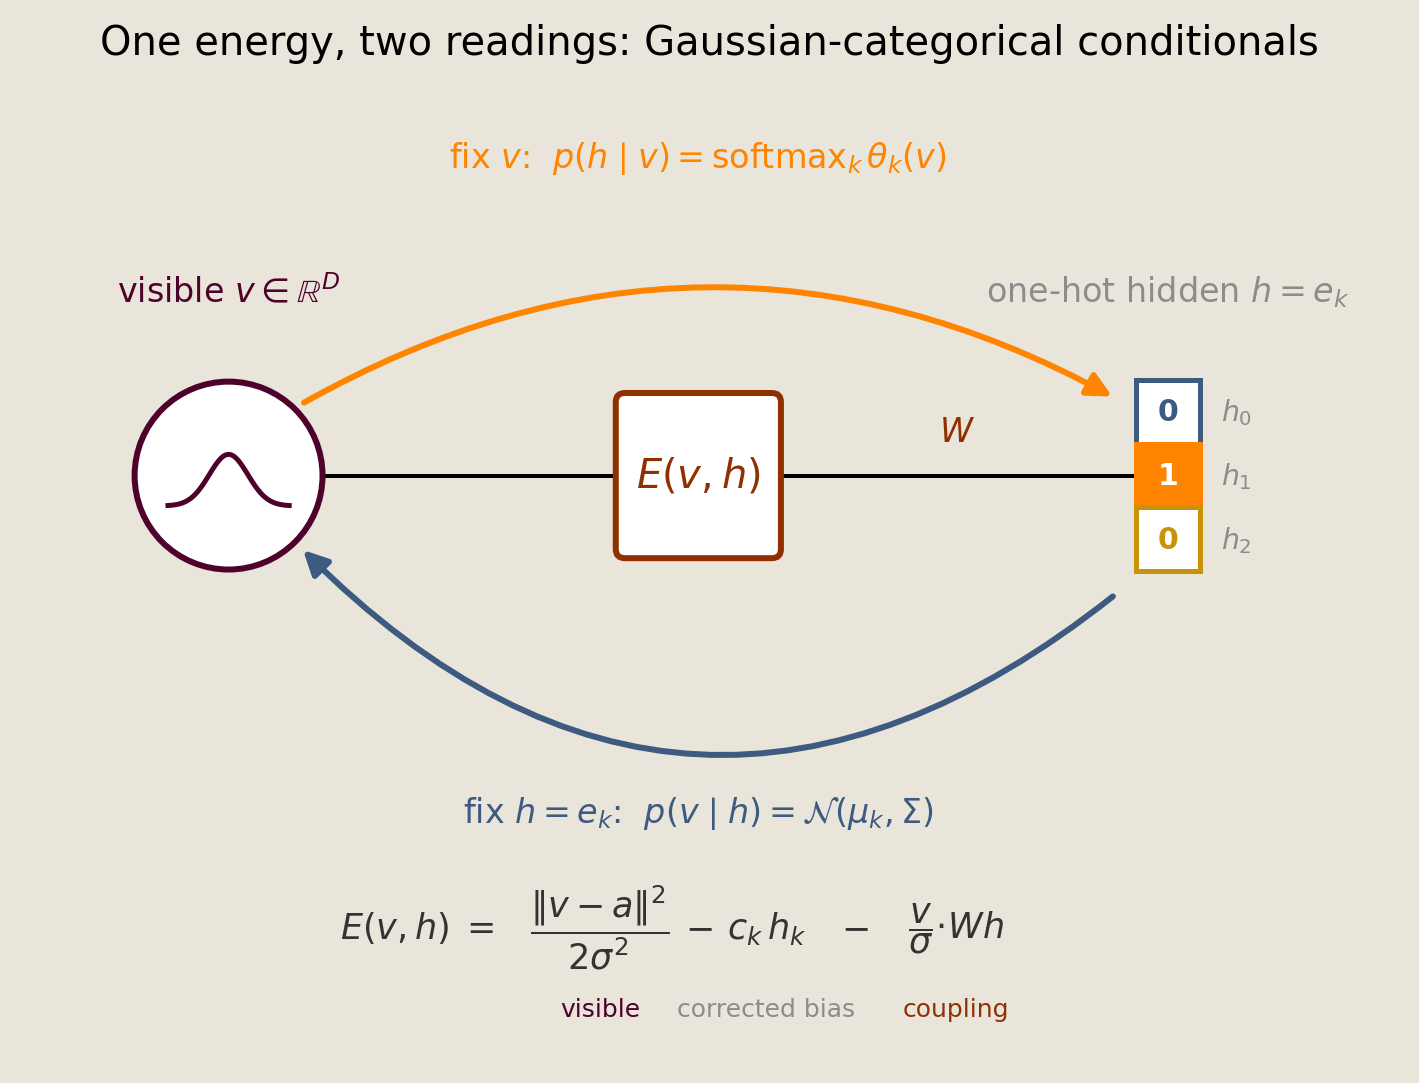

In [6]:
savefig(P_sch.energy_factor_graph(K), "14_energy_factor_graph")

Both directions run through the same factor: fixing $v$ gives the cluster probabilities, and fixing $h=e_k$ gives the Gaussian for cluster $k$.

## The softmax emerges

Taking the first reading, holding $v$ fixed leaves one component score per hidden state, which makes the categorical conditional a softmax:

$$
p(h=e_k\mid v)=\operatorname{softmax}_k(\theta(v)),\qquad
\theta_k(v)=\log\pi_k-\frac{1}{2}\sum_i\frac{(v_i-\mu_{ki})^2}{\sigma_{ki}^2}-\frac{1}{2}\sum_i\log\sigma_{ki}^2.
$$

The recovery section further down implements exactly this expression, in a function we'll meet there called `cluster_logits`. With shared covariance and the linear-coupling parameterization above, the same score is $\theta_k(v)=c_k+\sum_i(v_i/\sigma_i)W_{ik}$ plus a $k$-independent term, using the corrected $c_k$.

<details class="tx-disclosure"><summary>Term: responsibility</summary><p>A Gaussian-mixture responsibility is the posterior probability $p(h=e_k\mid v)$ that component $k$ generated a point, as in the mixture-model treatment of <a href="#ref-dempster-1977">Dempster et al. 1977</a>.</p></details>

The shape of the conditional comes from the hidden unit alone: a single bias `pbit` gives a sigmoid, while the one-hot `pdit` used here gives a softmax. The matching continuous conditional is supplied by `MixtureGaussianGate` in the next section.


## The Gaussian conditional and the gate

The second reading fixes $h=e_k$, which leaves the energy quadratic in $v$ and therefore Gaussian:

$$
p(v\mid h=e_k)=\mathcal{N}(v\mid\mu_k,\Sigma_k),\qquad p(v)=\sum_k \pi_k\,\mathcal{N}(v\mid\mu_k,\Sigma_k).
$$

The code works directly with $(\mu_k,\Sigma_k,\pi_k)$, the same parameters used by the energy and `cluster_logits`, so the two conditionals can't drift apart. For shared covariance, $\mu_k=a+\mathrm{diag}(\sigma)W_{:k}$ connects these parameters to the linear-coupling form above.

This Gaussian conditional is the piece Torx executes: `MixtureGaussianGate` realizes $p(v\mid h=e_k)$ and nothing else, with a single `pdit` storing the cluster index $k\in\{0,1,2\}$ directly.

Next, we construct `gate` and wrap it in a `HybridPCircuit` named `gen`. The circuit infers and preserves the gate's discrete control wire, so the seeded cluster label passes through unchanged.

In [7]:
mog_theta = {"means": cluster_means, "log_vars": log_vars}
# The MixtureGaussianGate is structure only; its means and log-variances live
# in the separate `thetas` list aligned with the circuit gates.
gate = MixtureGaussianGate(sites=(0, 0), dims=(2,), num_components=K)
gen = HybridPCircuit([gate])
thetas = [mog_theta]

We draw the circuit to see how little structure this model needs.

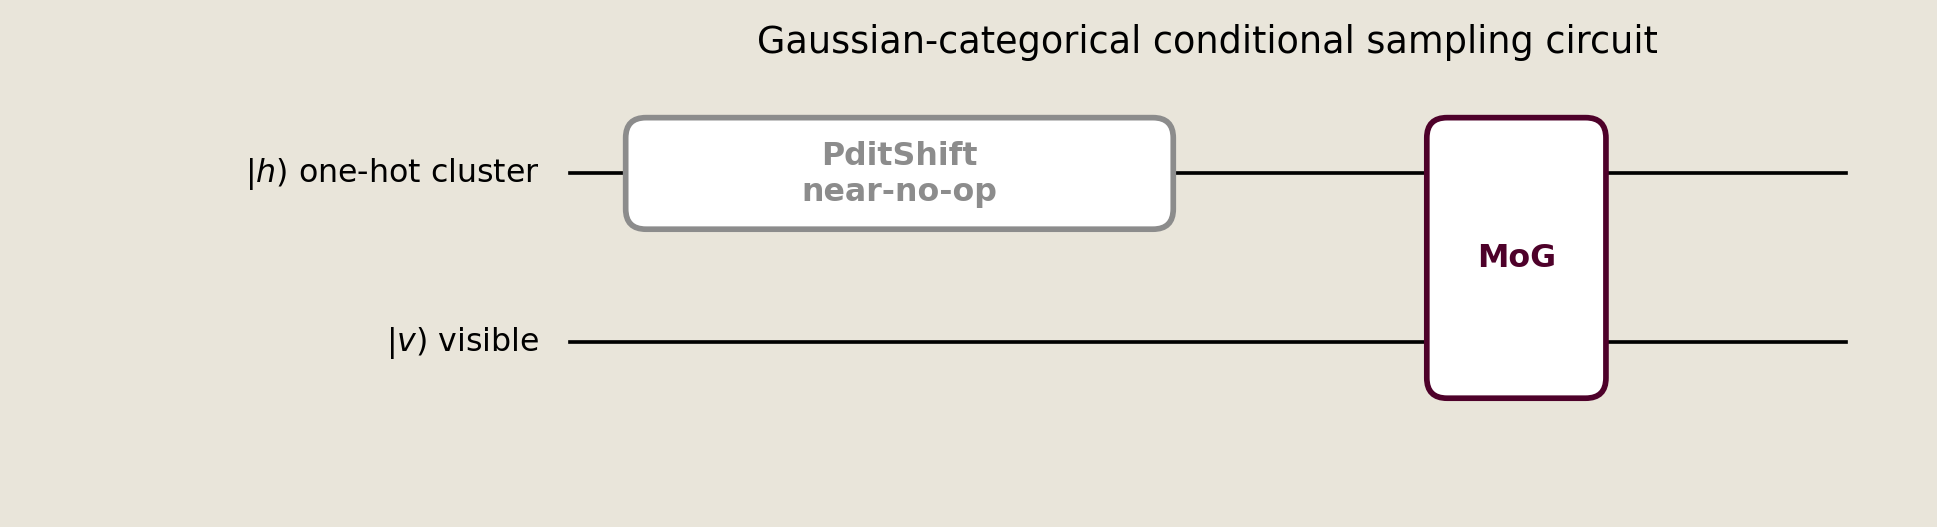

In [8]:
savefig(P_sch.cluster_gate_circuit(), "14_cluster_gate_circuit")

The whole Gaussian mixture is one hybrid gate: the categorical input passes through the near-no-op registration gate, then selects which Gaussian the continuous output comes from.


### Generating the clusters

To have something to cluster, we generate a labeled data set whose ground truth we know, splitting the work between two libraries. NumPy draws the component counts from $\pi$ and later shuffles the labeled blocks, and for each NumPy label $k$, Torx seeds the discrete state so that `MixtureGaussianGate` draws $v\sim\mathcal{N}(\mu_k,\Sigma_k)$.

A multinomial split sets the number of conditional samples requested from each cluster.


In [9]:
N_DATA = 9_000
rng_counts = np.random.default_rng(SEED)
counts = rng_counts.multinomial(N_DATA, np.asarray(pi))

In [10]:
def sample_labeled_mixture(circuit, params, counts):
    """Draw labeled visible samples for each requested cluster count."""
    point_blocks, label_blocks = [], []
    for k, count in enumerate(counts):
        # Seed the pdit to a cluster label, then draw the matching Gaussian block.
        s = circuit.sample_multiple(
            jax.random.key(SEED + 10 + k),
            {"discrete": jnp.array([k], dtype=jnp.int32), "continuous": jnp.zeros(2)},
            params,
            n_samples=int(counts.max()),
        )
        point_blocks.append(np.asarray(s["continuous"])[:count])
        label_blocks.append(np.full(count, k, dtype=np.int32))

    points = np.concatenate(point_blocks, axis=0)
    true_labels = np.concatenate(label_blocks, axis=0)
    # Shuffle the labeled blocks so the data look like a single mixed sample.
    order = np.random.default_rng(SEED + 1).permutation(int(counts.sum()))
    return points[order], true_labels[order]

With the per-cluster counts fixed, we draw the labeled samples directly from `gen`.

In [11]:
points, true_labels = sample_labeled_mixture(gen, thetas, counts)

sample_props = np.bincount(true_labels, minlength=K) / N_DATA
print(f"counts: {counts.tolist()}  proportions: {sample_props.round(3).tolist()}")

counts: [3686, 3091, 2223]  proportions: [0.41, 0.343, 0.247]


Before looking at any figure, we compute the sampled per-cluster moments, because they are the cheapest way to confirm that each block of Torx draws really came from the component we seeded.

In [12]:
cluster_sample_means = np.stack(
    [points[true_labels == k].mean(axis=0) for k in range(K)]
)
cluster_sample_vars = np.stack([points[true_labels == k].var(axis=0) for k in range(K)])

print("sampled means:")
print(np.round(cluster_sample_means, 3))
print("sampled diagonal variances:")
print(np.round(cluster_sample_vars, 3))

sampled means:
[[-0.02   3.005]
 [-2.594 -1.506]
 [ 2.592 -1.475]]
sampled diagonal variances:
[[0.452 0.438]
 [0.454 0.451]
 [0.44  0.422]]


The scatter plot puts the NumPy labels and the Torx conditional samples in one frame with the analytic one-sigma contours, so we can see whether the drawn points sit where the components say they should. The black circle around each cluster is the $1\sigma$ contour of $\mathcal{N}(\mu_k,\Sigma_k)$, and the $+$ marks the mean $\mu_k$.


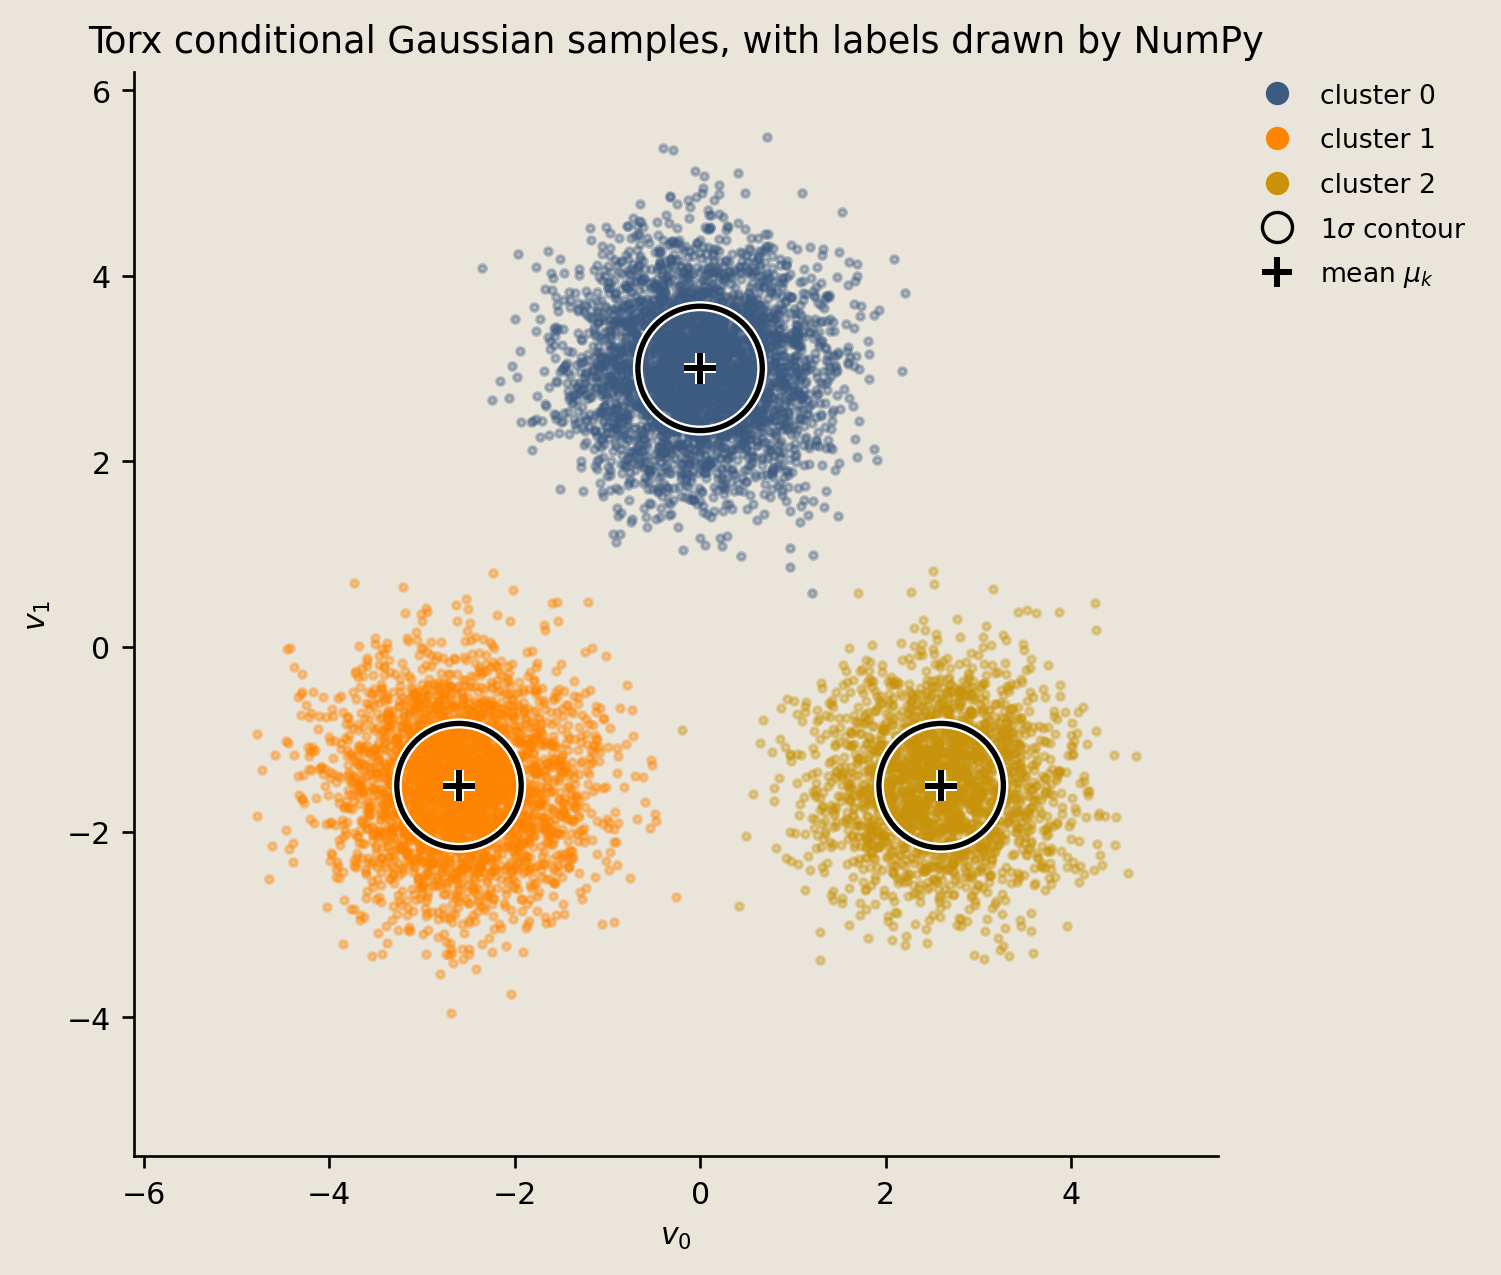

In [13]:
fig = P_fld.cluster_scatter(points, true_labels, np.asarray(cluster_means), cluster_covs)
savefig(fig, "14_generated_clusters")

## Recovering clusters with the softmax

Now we run the energy the other way and ask which cluster each sampled point came from, which is the softmax conditional evaluated at the data:

$$
p(h=e_k\mid v)=\frac{\exp[-E_k(v)]}{\sum_{k'}\exp[-E_{k'}(v)]}=\operatorname{softmax}_k(\theta(v)),\qquad \theta_k(v)=\log \pi_k-\frac{1}{2}(v-\mu_k)^\top\Sigma_k^{-1}(v-\mu_k)-\frac{1}{2}\log\det\Sigma_k.
$$

This is the Gaussian-mixture responsibility from the opening energy, because the logits are the negated component energies with shared constants removed, so each row is the one-hot Boltzmann conditional.

The log-determinant is required when covariances differ, and with the shared diagonal covariance used here it cancels in the softmax.

The `cluster_logits` function below builds these logits from the component energies.


In [14]:
def cluster_logits(v):
    """Return the per-cluster Boltzmann logits for visible points v."""
    v = jnp.atleast_2d(jnp.asarray(v, dtype=jnp.float32))
    diff = v[:, None, :] - cluster_means[None, :, :]
    inv_vars = jnp.exp(-log_vars)
    # Lower Gaussian energy means a larger logit for that cluster. The
    # 0.5*sum(log_vars_k) component normalizer is required so marginalizing v
    # reproduces pi under per-cluster (not just shared) covariance.
    energy = (
        0.5 * jnp.sum(diff**2 * inv_vars[None, :, :], axis=-1)
        + 0.5 * jnp.sum(log_vars, axis=-1)[None, :]
        - jnp.log(pi)
    )
    return -energy




In [15]:
def posterior_probs(v):
    """Softmax the cluster logits into responsibilities."""
    return jax.nn.softmax(cluster_logits(v), axis=1)

`posterior_probs` softmaxes those logits into responsibilities, from which we take the hard label $\arg\max_k p(k\mid v)$ and the fraction of points whose top responsibility falls below 0.92, a soft-boundary score counting how many points are genuinely ambiguous. We then plot the hard labels on top of the soft responsibility field.

In [16]:
post_probs = np.asarray(posterior_probs(points))
hard_labels = post_probs.argmax(axis=1)
hard_accuracy = float((hard_labels == true_labels).mean())
soft_boundary_rate = float((post_probs.max(axis=1) < 0.92).mean())

print(f"hard reassignment accuracy: {hard_accuracy:.3f}")
print(f"soft boundary fraction:     {soft_boundary_rate:.3f}")

hard reassignment accuracy: 1.000
soft boundary fraction:     0.000


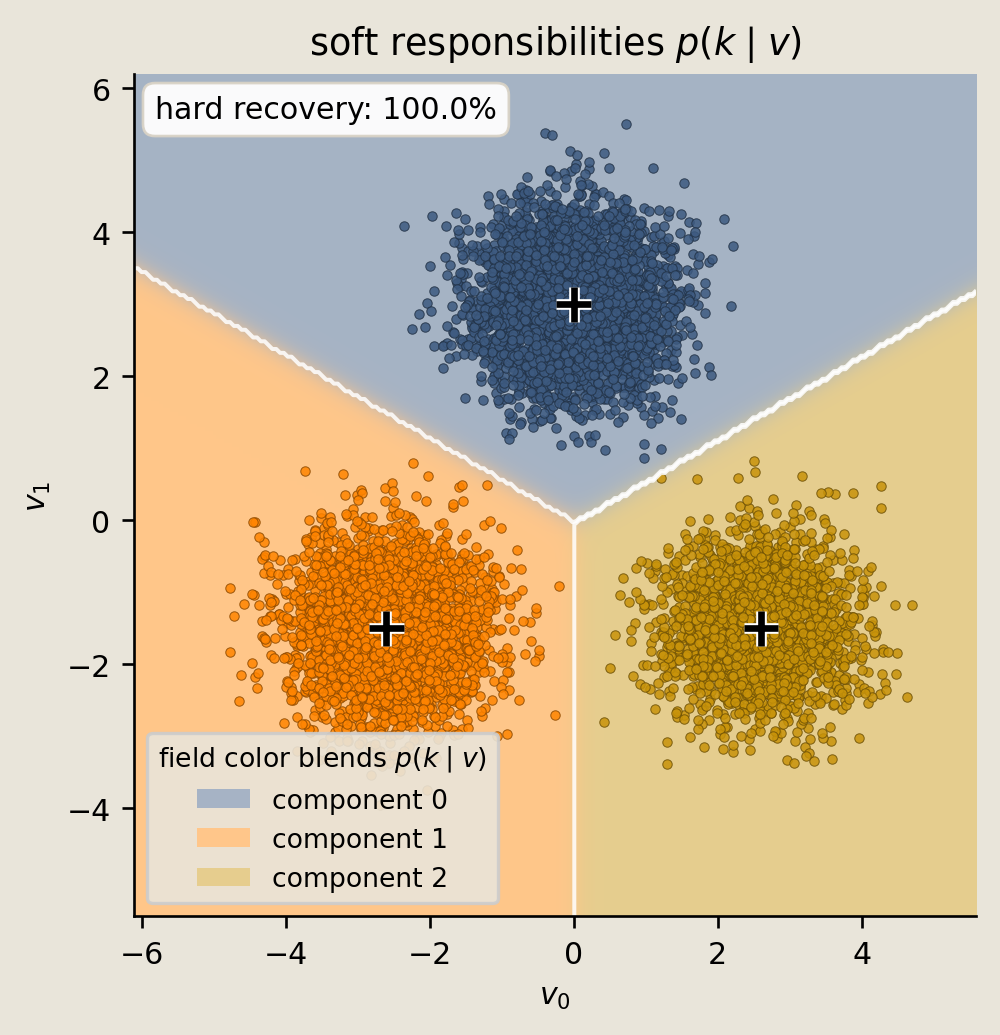

In [17]:
fig = P_fld.assignment_panels(
    points,
    true_labels,
    post_probs,
    np.asarray(cluster_means),
    posterior_fn=posterior_probs,
)
savefig(fig, "14_soft_assignment")

The assignment figure overlays the hard $\arg\max_k p(k\mid v)$ labels on the soft responsibility field, whose component colors blend to encode $p(k\mid v)$. Every point is recovered with a near-certain responsibility, at a printed hard reassignment accuracy of 1.000 and a soft boundary fraction of 0.000, and the field blends between colors only in the empty regions between clusters, where no data live.


One more check on the generated data closes this section. We compare the histogram of a single visible coordinate against the exact mixture density for that coordinate, which tests the marginal rather than the per-cluster blocks. The density comes from `mixture_density`, a notebook helper in `examples/helpers/_affine_gaussian.py` that evaluates the analytic Gaussian mixture on a grid.

In [18]:
marginal_dim = 0
grid = np.linspace(
    points[:, marginal_dim].min() - 0.7, points[:, marginal_dim].max() + 0.7, 420
)
density = np.asarray(
    mixture_density(
        cluster_means[:, marginal_dim : marginal_dim + 1],
        log_vars[:, marginal_dim : marginal_dim + 1],
        pi,
        jnp.asarray(grid),
    )
)

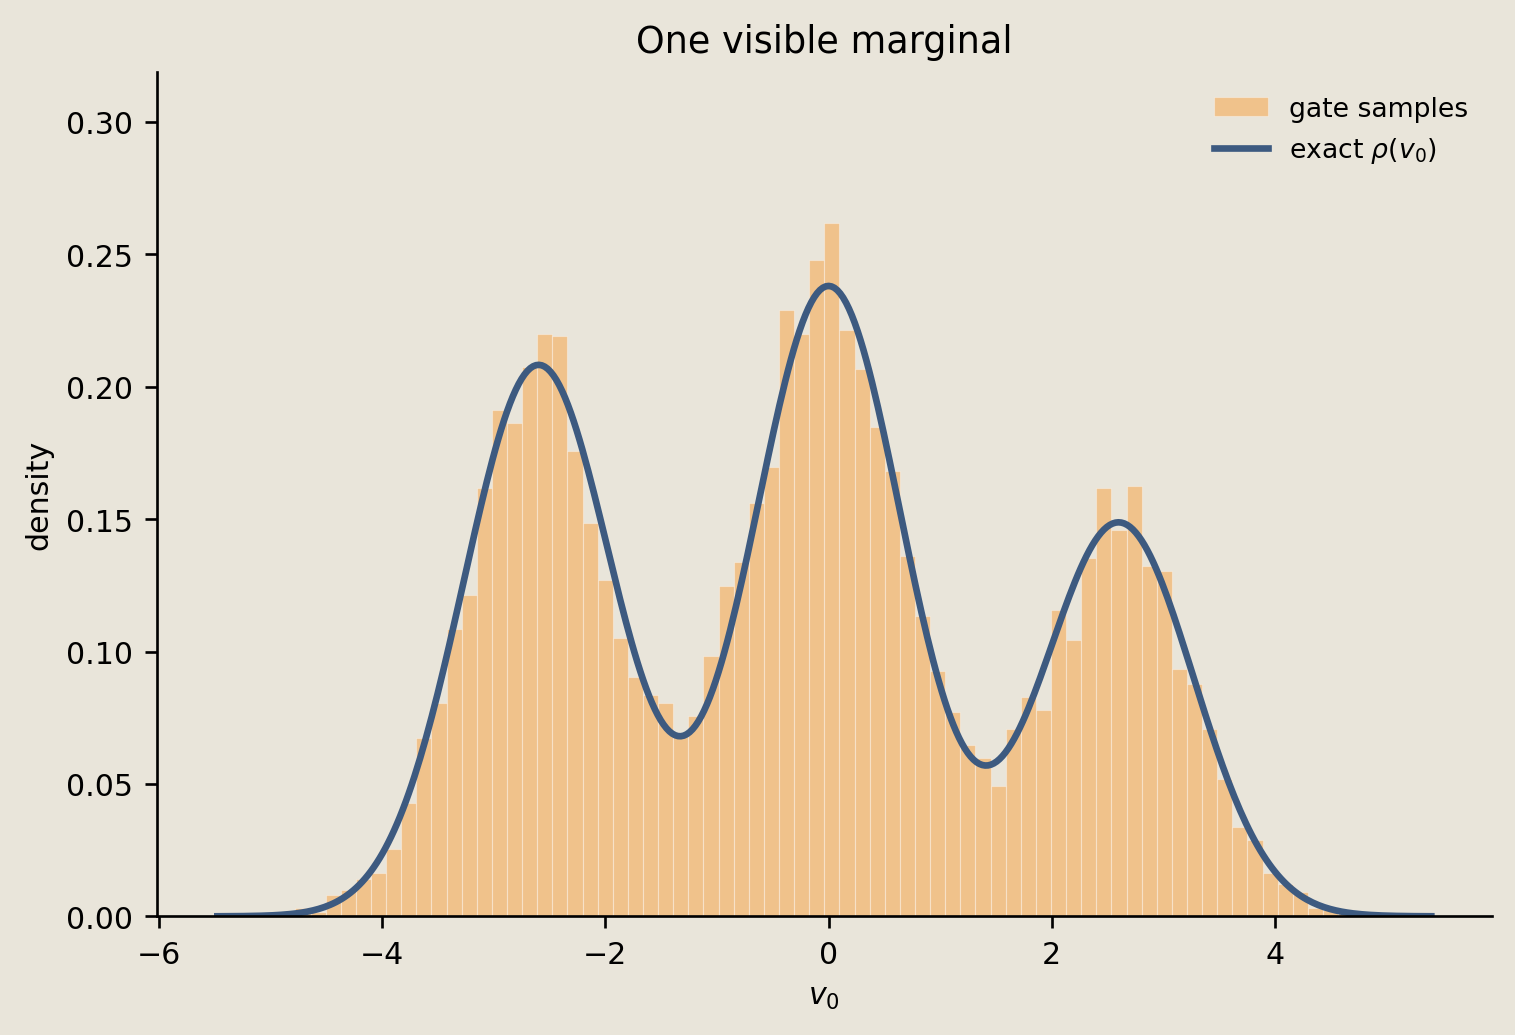

In [19]:
fig = P_fld.marginal_density(points[:, marginal_dim], grid, density)
savefig(fig, "14_marginal_density")

For the selected coordinate, the sampled histogram follows the analytic mixture density, so the marginal of the generated data reproduces the mixture we specified.

## Block Gibbs on the joint Boltzmann machine

With both conditionals in hand we can stop conditioning on fixed data and sample the joint law itself, by alternating them:

$$
h\sim p(h\mid v)=\operatorname{softmax}(\theta(v)),\qquad v\sim p(v\mid h=e_k)=\mathcal{N}(v\mid\mu_k,\Sigma_k).
$$

We implement both updates directly in JAX from these same formulas, so the Gibbs mechanics stay visible line by line, which means Torx's role in this notebook ends with the conditional Gaussian draws above. One sweep redraws each visible point from its current component, then redraws its label from the analytic responsibility vector.

<details class="tx-disclosure"><summary>Term: Gibbs sweep</summary><p>A <a href="#ref-geman-1984">block Gibbs sweep (Geman and Geman 1984)</a> redraws each variable block from its conditional distribution while holding the other block fixed.</p></details>

Mixing speed depends on cluster overlap, and the well-separated mixture above would leave chains almost frozen in whichever cluster they started, so this convergence study uses closer means and a larger shared variance. Every chain starts in cluster 0, which is as far off-stationary as the population can be, and the per-sweep population occupancy then relaxes toward $\pi$. The curves need not sit exactly on the dashed targets, because a finite population of chains carries sampling noise of its own.


In [20]:
# the convergence study needs a mixture block Gibbs can actually mix
# on. the clustering demo above keeps well-separated means, where a chain never
# hops, so its population occupancy would be frozen by its start. these closer
# means with a larger shared variance overlap enough that the hidden block
# genuinely reassigns chains between clusters within a few tens of sweeps.
conv_means = jnp.array(
    [[0.0, 1.6], [-1.44, -0.88], [1.44, -0.88]], dtype=jnp.float32
)
conv_vars = jnp.full((K, 2), 0.9, dtype=jnp.float32)
conv_log_vars = jnp.log(conv_vars)

In [21]:
def conv_cluster_logits(v):
    """Per-cluster Boltzmann logits for the overlapping convergence mixture."""
    v = jnp.atleast_2d(jnp.asarray(v, dtype=jnp.float32))
    diff = v[:, None, :] - conv_means[None, :, :]
    inv_vars = jnp.exp(-conv_log_vars)
    # per-cluster log-det normalizer so the logits stay valid GMM responsibilities.
    energy = (
        0.5 * jnp.sum(diff**2 * inv_vars[None, :, :], axis=-1)
        + 0.5 * jnp.sum(conv_log_vars, axis=-1)[None, :]
        - jnp.log(pi)
    )
    return -energy

In [22]:
conv_sigma = jnp.sqrt(jnp.exp(conv_log_vars))


def gibbs_visible_step(labels, key):
    """Visible block: draw each chain directly from its component Gaussian."""
    mu = conv_means[labels]
    sigma = conv_sigma[labels]
    return mu + sigma * jax.random.normal(key, mu.shape)

In [23]:
def gibbs_hidden_step(v, key):
    """Hidden block: draw labels from the analytic GMM logits."""
    return jax.random.categorical(key, conv_cluster_logits(v), axis=1)

In [24]:
def _occupancy(labels, num_clusters):
    """Fraction of chains currently in each cluster."""
    return jnp.bincount(labels, length=num_clusters) / labels.shape[0]

In [25]:
@eqx.filter_jit
def run_gibbs_chain(key, num_chains, num_sweeps):
    # start every chain committed to cluster 0, so the population begins fully
    # off-stationary at (1, 0, 0). vmap is implicit (all chains are batched
    # array rows); lax.scan walks the sweeps under one compile.
    """Run block Gibbs from the all-cluster-0 start and record occupancy per sweep."""
    labels0 = jnp.zeros(num_chains, dtype=jnp.int32)

    def step(labels, key):
        kv, kh = jax.random.split(key)
        v = gibbs_visible_step(labels, kv)
        new_labels = gibbs_hidden_step(v, kh)
        return new_labels, _occupancy(new_labels, K)

    keys = jax.random.split(key, num_sweeps)
    _, swept = jax.lax.scan(step, labels0, keys)
    # prepend the seeded (1, 0, 0) start so the trace shows the full relaxation
    return jnp.concatenate([_occupancy(labels0, K)[None, :], swept], axis=0)

We run 30 Gibbs sweeps over 6,000 chains and record the occupancy at each sweep, which gives us the whole relaxation curve rather than only its endpoint.

In [26]:
N_GIBBS = 6_000
NUM_SWEEPS = 30

gibbs_occupancy = np.asarray(
    run_gibbs_chain(jax.random.key(SEED + 900), N_GIBBS, NUM_SWEEPS)
)
gibbs_sweeps = np.arange(len(gibbs_occupancy))
# the equilibrium check pools the back half, after the transient relaxes
gibbs_back_half = gibbs_occupancy[len(gibbs_occupancy) // 2 :].mean(axis=0)

print(f"start occupancy:     {gibbs_occupancy[0].round(3).tolist()}")
print(f"back-half occupancy: {gibbs_back_half.round(3).tolist()}")
print(f"target weights pi:   {np.asarray(pi).round(3).tolist()}")

start occupancy:     [1.0, 0.0, 0.0]
back-half occupancy: [0.40299999713897705, 0.3499999940395355, 0.2460000067949295]
target weights pi:   [0.4000000059604645, 0.3499999940395355, 0.25]


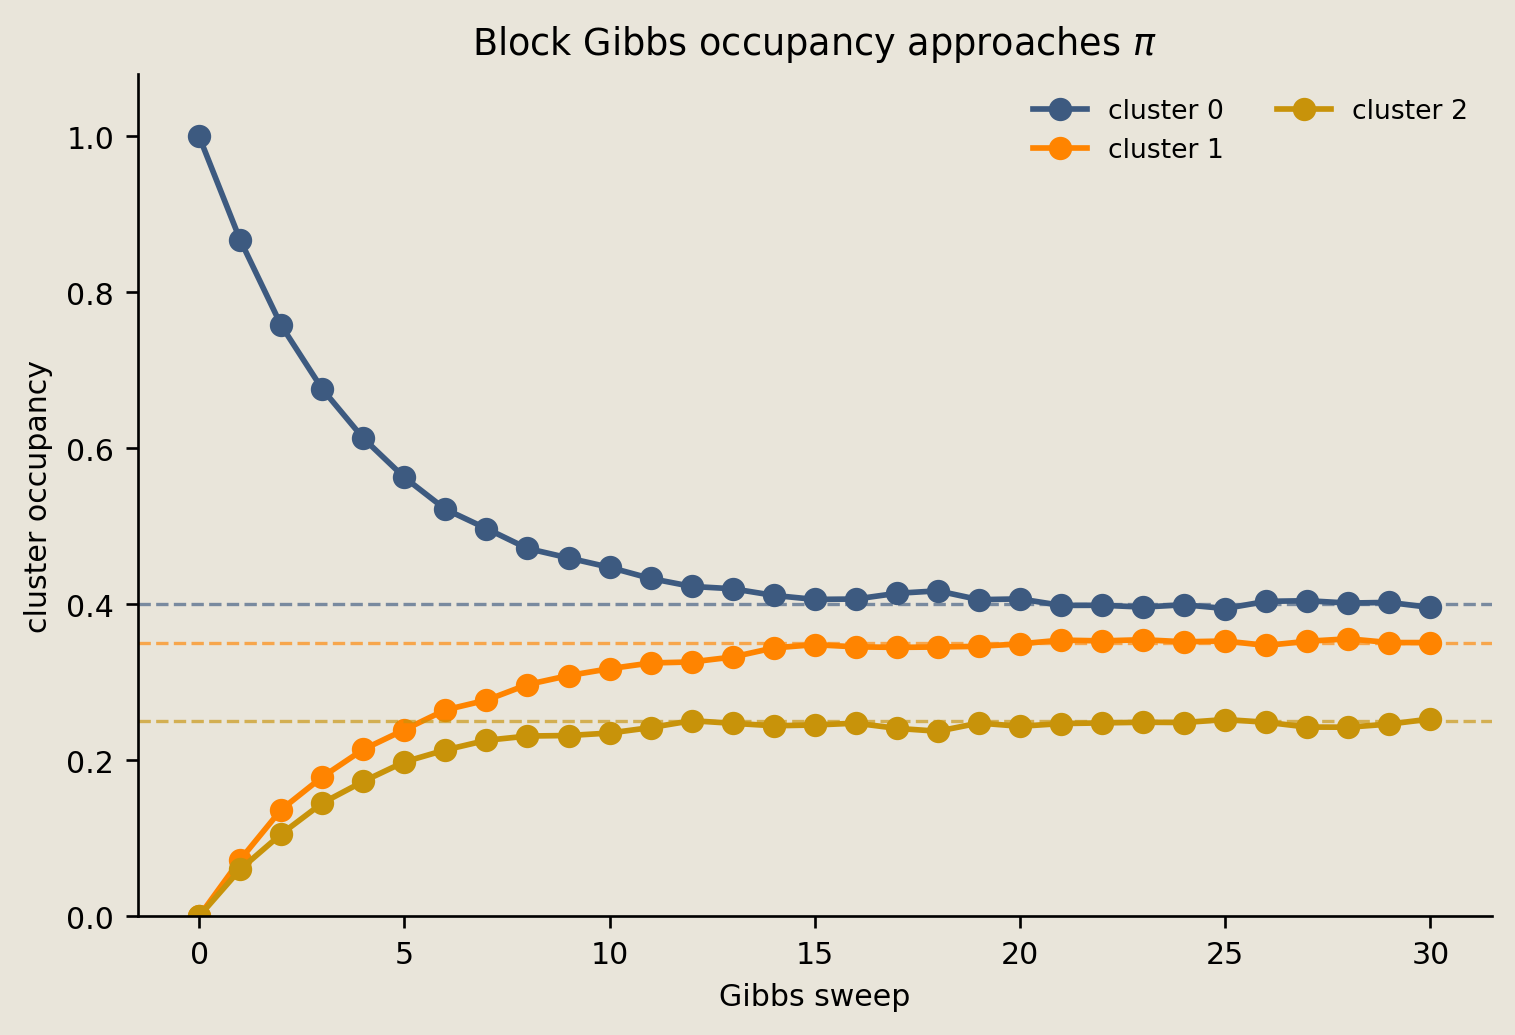

In [27]:
fig = P_samp.gibbs_convergence(gibbs_sweeps, gibbs_occupancy, np.asarray(pi))
savefig(fig, "14_gibbs_convergence")

The occupancy leaves its seeded $(1, 0, 0)$ start within a few sweeps and then flattens out. Pooling the back half of the sweeps, after that transient, gives $(0.403, 0.350, 0.246)$ against the target weights $\pi=(0.400, 0.350, 0.250)$, so the handwritten JAX chain reproduces the mixture weights to within 0.004 per component, the size of the finite-population sampling noise here.


## The one-hot constraint as a winner-take-all energy

We close by building the energetic alternative named at the start, so the structural choice this notebook made can be compared against it at a definite penalty strength. Recall from the opening energy section that the one-hot constraint can be written as the penalty energy over binary units $z\in\{0,1\}^K$:

$$
E_{\mathrm{WTA}}(z) = \lambda\Big(\sum_k z_k - 1\Big)^2,
$$

whose ground states are exactly the one-hot vectors $e_k$. Up to the constant $\lambda$, the penalty expands into a bias term $-\lambda\sum_k z_k$ plus an all-pairs repulsion $2\lambda\sum_{k<k'} z_k z_{k'}$, a winner-take-all Potts-type coupling.

Its Boltzmann distribution $p(z)\propto e^{-E_{\mathrm{WTA}}(z)}$ therefore concentrates on those one-hot states, and by symmetry it assigns them equal probability. At finite $\lambda$ it still leaks mass onto non-one-hot configurations, which the sweep below makes visible, so it equals the structural $K$-state `pdit` only in the $\lambda\to\infty$ limit, or once restricted to the one-hot subset. Increasing $\lambda$ sharpens the concentration toward that uniform categorical.

Here we enumerate all $2^K$ binary configurations and compute the exact finite Boltzmann distribution of the energy directly, so no sampling error enters the comparison. On hardware, the same penalty can be realized with pairwise couplings, but the equilibrium object below is the energy distribution itself.

In [28]:
wta_K = 3
wta_lambda = 4.0
# Enumerate every binary configuration so the finite distribution is exact.
wta_configs = np.array(list(np.ndindex(*(2,) * wta_K)), dtype=np.int32)
wta_config_labels = np.array(["".join(map(str, z)) for z in wta_configs])
wta_is_onehot = wta_configs.sum(axis=1) == 1

With only $2^K$ configurations to sum over, the normalized Boltzmann probability of each one follows directly from its penalty energy.


In [29]:
def wta_probabilities(lam):
    energies = lam * (wta_configs.sum(axis=1) - 1) ** 2
    weights = np.exp(-energies)
    return weights / weights.sum(), energies

We evaluate that distribution at $\lambda=4$ and total the mass sitting on one-hot states, which is the number that says how closely the penalty imitates a `pdit`.

In [30]:
wta_probs, wta_energies = wta_probabilities(wta_lambda)
wta_onehot_mass = float(wta_probs[wta_is_onehot].sum())
wta_onehot_probs = wta_probs[wta_is_onehot]

wta_lambdas = np.linspace(0.0, 6.0, 25)
wta_onehot_sweep = np.array(
    [wta_probabilities(lam)[0][wta_is_onehot].sum() for lam in wta_lambdas]
)

print(f"lambda = {wta_lambda:.1f}")
print(f"P(one-hot) = {wta_onehot_mass:.6f}")
print("per-one-hot probabilities:", np.round(wta_onehot_probs, 6).tolist())

lambda = 4.0
P(one-hot) = 0.976161
per-one-hot probabilities: [0.325387, 0.325387, 0.325387]


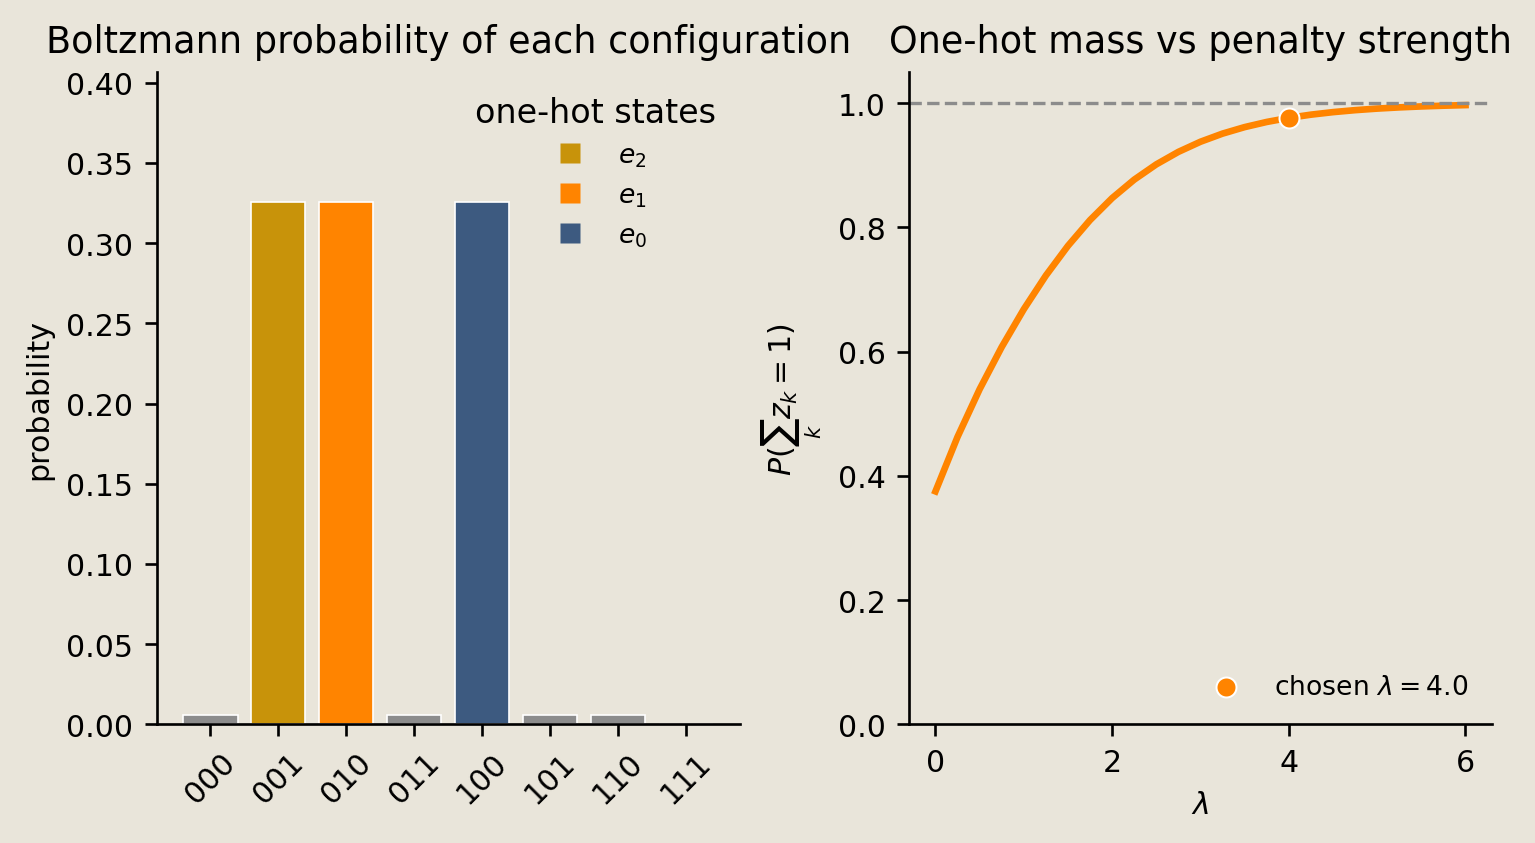

In [31]:
fig = P_samp.winner_take_all(
    wta_config_labels,
    wta_probs,
    wta_is_onehot,
    wta_lambdas,
    wta_onehot_sweep,
)
savefig(fig, "14_winner_take_all_energy")

At $\lambda=4$ the three one-hot states share the mass equally at 0.325387 each, for a one-hot total of 0.976161, and the sweep over $\lambda$ shows that total rising as the penalty grows. The remaining 0.024 sits on configurations that a $K$-state `pdit` can't represent at all, which is the price of the energetic route at finite $\lambda$.

## Verification

The figures above are readings, so we finish by asserting the numbers behind them.

First the generated data against the parameters we asked for. Each cluster's sampled mean matches $\mu_k$ within 0.06 and its sampled variance matches $\sigma_k^2$ within 12% relative, and the realized label proportions match $\pi$ within 0.025, so the NumPy-and-Torx generation path is faithful to the model it claims to sample.

Then the inference path. Every responsibility row sums to one within $10^{-6}$, and the softmax of our Boltzmann logits matches responsibilities assembled independently from per-component Gaussian densities within $10^{-4}$, which is the claim that the energy view and the textbook mixture view are the same computation. Hard reassignment accuracy is asserted above 0.99, confirming that clusters this well separated are recoverable from the responsibilities alone.

Next, the pooled sample mean and variance of the visible data match the analytic mixture moments within 0.08 and 5% relative, so the full marginal is right as well as the per-cluster blocks checked earlier.

For the Gibbs chain we assert both ends. The seeded start really is off-stationary, with over 95% of chains in cluster 0, and the back-half occupancy is within 0.04 of $\pi$ in every component, which together make the trace a relaxation rather than a chain that began at its target.

Finally, the winner-take-all distribution puts over 95% of its mass on one-hot states, spreads that mass equally across them to within $10^{-9}$, and increases monotonically in $\lambda$, matching the three claims made for it above.

In [32]:
for k in range(K):
    mask = true_labels == k
    np.testing.assert_allclose(
        points[mask].mean(axis=0), np.asarray(cluster_means[k]), atol=0.06
    )
    np.testing.assert_allclose(
        points[mask].var(axis=0), np.asarray(cluster_vars[k]), rtol=0.12
    )

In [33]:
np.testing.assert_allclose(sample_props, np.asarray(pi), atol=0.025)
np.testing.assert_allclose(post_probs.sum(axis=1), 1.0, atol=1e-6)

# energy-to-responsibility equivalence: softmax of the Boltzmann logits must
# equal the GMM responsibilities built directly from per-component densities.
ref_comp = np.stack(
    [
        np.asarray(pi[k])
        * np.exp(
            -0.5
            * np.sum(
                (points - np.asarray(cluster_means[k])) ** 2
                / np.asarray(cluster_vars[k]),
                axis=1,
            )
        )
        / np.sqrt(np.prod(2 * np.pi * np.asarray(cluster_vars[k])))
        for k in range(K)
    ],
    axis=1,
)
ref_resp = ref_comp / ref_comp.sum(axis=1, keepdims=True)
np.testing.assert_allclose(post_probs, ref_resp, atol=1e-4)

assert hard_accuracy > 0.99, f"hard assignment accuracy too low: {hard_accuracy:.3f}"

In [34]:
analytic_mean = np.asarray((pi[:, None] * cluster_means).sum(axis=0))
analytic_second = np.asarray(
    (pi[:, None] * (cluster_vars + cluster_means**2)).sum(axis=0)
)
analytic_var = analytic_second - analytic_mean**2
np.testing.assert_allclose(points.mean(axis=0), analytic_mean, atol=0.08)
np.testing.assert_allclose(points.var(axis=0), analytic_var, rtol=0.05)

In [35]:
# the chain genuinely starts off-stationary (all mass in cluster 0) and relaxes
assert gibbs_occupancy[0, 0] > 0.95, (
    f"Gibbs chain not seeded off-stationary: start {gibbs_occupancy[0].round(3)}"
)
max_gibbs_dev = float(np.max(np.abs(gibbs_back_half - np.asarray(pi))))
assert max_gibbs_dev < 0.04, f"Gibbs occupancy deviation {max_gibbs_dev:.4f} >= 0.04"

In [36]:
assert wta_onehot_mass > 0.95, f"WTA one-hot mass {wta_onehot_mass:.6f} <= 0.95"
np.testing.assert_allclose(wta_onehot_probs, wta_onehot_probs[0], atol=1e-9)
assert np.all(np.diff(wta_onehot_sweep) >= -1e-12), "WTA one-hot mass is not monotone"
print("all checks passed")

all checks passed


## Conclusion

This tutorial wrote a Gaussian-categorical mixture as one Boltzmann machine, then ran that single energy from both sides.

The analytic joint energy uses the same $(\mu_k,\Sigma_k,\pi_k)$ parameterization as the executed JAX logits, which is what lets the derivation on paper and the running code check each other. Generation split across two libraries: NumPy drew the labels and shuffled the blocks, while Torx `MixtureGaussianGate` drew the conditional Gaussian samples and nothing else. Recovery was pure JAX, computing the responsibilities and the hard assignments taken from them. The closing block Gibbs section then alternated the two conditional formulas in a separate handwritten JAX loop, which kept every step of a sweep on the page.

See also:
- [`10_pmode_gaussian_gates.ipynb`](10_pmode_gaussian_gates.ipynb), pure Gaussian gates and closed-form Gaussian conditioning.
- [`13_regime_switching_diffusion.ipynb`](13_regime_switching_diffusion.ipynb), `pdit`-selected Gaussian increments in a hybrid process.


## References

1. <span id="ref-ackley-1985"></span>Ackley, D.H., Hinton, G.E., Sejnowski, T.J. 1985. [*A learning algorithm for Boltzmann machines*](https://www.cs.toronto.edu/~hinton/absps/cogscibm.pdf). Cognitive Science 9(1), 147-169. Foundational Boltzmann-machine definition and equilibrium treatment.
2. <span id="ref-dempster-1977"></span>Dempster, A.P., Laird, N.M., Rubin, D.B. 1977. [*Maximum likelihood from incomplete data via the EM algorithm*](https://doi.org/10.1111/j.2517-6161.1977.tb01600.x). Journal of the Royal Statistical Society B 39(1), 1-38. Introduces the responsibility, the posterior over mixture components used throughout this notebook.
3. <span id="ref-geman-1984"></span>Geman, S., Geman, D. 1984. [*Stochastic relaxation, Gibbs distributions, and the Bayesian restoration of images*](https://doi.org/10.1109/TPAMI.1984.4767596). IEEE Transactions on Pattern Analysis and Machine Intelligence 6(6), 721-741. Introduces Gibbs sampling as stochastic relaxation toward a Boltzmann distribution, the block sweep run above.
